# Multi-objective Diet Optimization — Experiments

This notebook is the **main entrypoint** to run experiments, generate plots, and export results for the report.

It runs:
- **NSGA-II** (evolutionary, multi-objective) using a **discrete constraint-respecting encoding**
- **PSO** (swarm, single-objective) using a **continuous encoding** decoded to the same discrete meal plan

## Requirements (real data)

This notebook uses the **real dataset** from the MySQL database described by the provided SQL dump.

You must:
1. Create/import the DB from `data/food_database_dump.sql`
2. Create a `.env` file (copy `.env.example`) with your MySQL credentials
3. Ensure MySQL is running and reachable from this machine

If DB credentials are missing, the notebook will raise a clear error telling you what to set.

In [ ]:
# Make `src/` importable so we can `import dietopt` and `import utilidades`
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "src").is_dir():
            return p
    raise RuntimeError("Could not find repo root containing 'src/'")


repo_root = _find_repo_root(Path.cwd())
src_root = repo_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

print("cwd:", Path.cwd())
print("repo_root:", repo_root)
print("src_root:", src_root)
print("python:", sys.executable)

cwd: c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\notebooks
repo_root: c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem
python: c:\Users\ismadels\Projects\Multi-objective-Diet-Optimization-Problem\.venv\Scripts\python.exe


In [ ]:
import matplotlib.pyplot as plt

from dietopt.data import load_foods_from_db, load_subjects_from_db, require_db_env
from dietopt.plotting import plot_convergence, plot_pareto
from dietopt.algorithms.nsga2 import run_nsga2
from dietopt.algorithms.pso import run_pso_scalarized

require_db_env()

USE_DB = False


In [ ]:
foods = load_foods_from_db()
subjects = load_subjects_from_db()
subject = subjects[0]

print("n_foods =", len(foods))
print("subject =", subject)

n_foods = 15
subject = SubjectProfile(sujeto_id=1, edad=25, calorias=2000.0, gustos=[], disgustos=[], alergias=[])


In [6]:
# Quick demo run (keep generations small for interactivity)
nsga = run_nsga2(foods, subject.edad, subject.calorias, pop_size=60, max_generations=40, seed=1)
pso  = run_pso_scalarized(foods, subject.edad, subject.calorias, pop_size=50, max_generations=40, seed=1)

print('NSGA-II best_f (representative):', nsga['best_f'])
print('PSO best_f:', pso['best_f'])

NSGA-II best_f (representative): (3520.0, 42.73594776307377)
PSO best_f: (3558.0, 50.259418564460994)


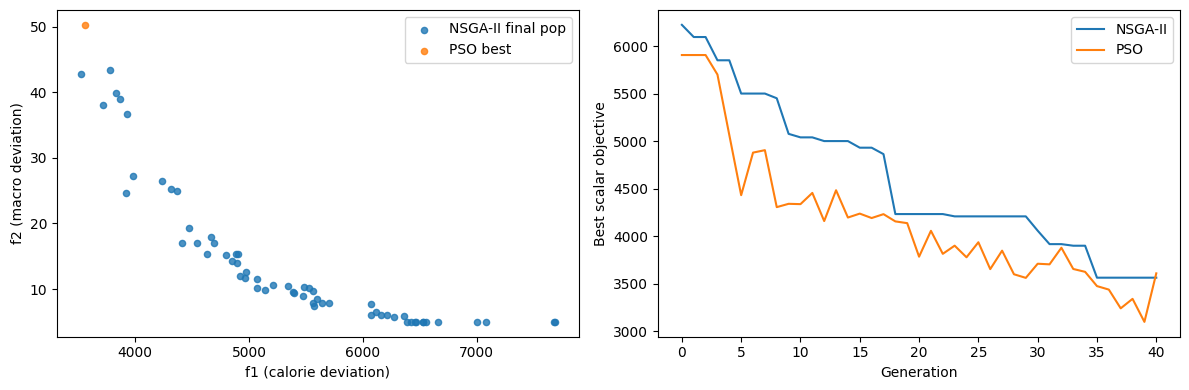

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pareto(nsga['front'], axes[0], label='NSGA-II final pop')
plot_pareto(pso['front'], axes[0], label='PSO best')
axes[0].legend()

plot_convergence(nsga['trace'], axes[1], label='NSGA-II')
plot_convergence(pso['trace'], axes[1], label='PSO')
axes[1].legend()

plt.tight_layout()
plt.show()

## How to run the required 30+ executions

Use `dietopt.experiments.run_replicates(...)` and set `n_runs=30` (or more).
Then compare algorithms/configurations using the Mann–Whitney U test (see `mann_whitney_u_p_value`).

In [ ]:
import pandas as pd
from IPython.display import display

from dietopt.experiments import mann_whitney_u_p_value, run_replicates

# For the report: set n_runs = 30 (or more).
n_runs = 5

nsga_runs = run_replicates(
    "NSGA-II",
    run_nsga2,
    n_runs=n_runs,
    seed0=100,
    comida_bd=foods,
    edad=subject.edad,
    ctarget=subject.calorias,
    pop_size=60,
    max_generations=40,
)

pso_runs = run_replicates(
    "PSO",
    run_pso_scalarized,
    n_runs=n_runs,
    seed0=200,
    comida_bd=foods,
    edad=subject.edad,
    ctarget=subject.calorias,
    pop_size=50,
    max_generations=40,
)

df = pd.DataFrame([r.__dict__ for r in (nsga_runs + pso_runs)])
display(df.groupby("algorithm")[["f1", "f2", "runtime_s"]].agg(["mean", "std", "min", "max"]))

p_f1 = mann_whitney_u_p_value(df[df.algorithm == "NSGA-II"].f1, df[df.algorithm == "PSO"].f1)
p_f2 = mann_whitney_u_p_value(df[df.algorithm == "NSGA-II"].f2, df[df.algorithm == "PSO"].f2)
print("Mann–Whitney p-value (f1):", p_f1)
print("Mann–Whitney p-value (f2):", p_f2)

f1                                     f2                       \
             mean         std     min     max       mean       std        min   
algorithm                                                                       
NSGA-II    3580.8  321.464150  3237.0  3965.0  33.140514  8.689245  19.130670   
PSO        3542.4  327.819005  3111.0  3810.0  48.652921  7.316902  41.008958   

                     runtime_s                                
                 max      mean       std       min       max  
algorithm                                                     
NSGA-II    41.535811  0.725758  0.152808  0.629367  0.990352  
PSO        60.141150  0.276270  0.020050  0.258060  0.297904

Mann–Whitney p-value (f1): 1.0
Mann–Whitney p-value (f2): 0.015873015873015872
